# Task 4 — Rolling-window DCC

Backward-looking Engle (2002) DCC-GARCH:
1. Fit univariate GARCH(1,1) on each asset in the window `[t-W, t)`.
2. Fit DCC(1,1) on the standardized residuals (composite pairwise likelihood).
3. Record the one-step-ahead correlation `R_t` (information through `t-1` only).

Parameters are refit every `step` trading days. Between refits the filter is updated with newly observed returns, still without look-ahead.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dcc import load_panel, log_returns, rolling_dcc, RollingDCCResult

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_context("notebook")

ART = Path("artifacts")
NPZ = ART / "dcc_rolling.npz"

In [2]:
panel = load_panel()
rets = log_returns(panel)
print(rets.shape, rets.index.min().date(), "->", rets.index.max().date())

(2510, 100) 2016-01-26 -> 2026-01-16


Train if artifacts are missing. Same defaults as `python train.py` (252-day window, monthly refit).

In [3]:
WINDOW, STEP, N_ASSETS = 252, 21, 100

if NPZ.exists():
    result = RollingDCCResult.load(NPZ)
    print("loaded", NPZ)
else:
    result = rolling_dcc(rets, window=WINDOW, step=STEP, n_assets=N_ASSETS)
    result.save(NPZ)

mean_corr = result.mean_corr()
print(result.dates[0].date(), "->", result.dates[-1].date(), "n=", len(result.assets))
print(
    f"mean ρ  min={mean_corr.min():.3f} ({mean_corr.idxmin().date()})  "
    f"max={mean_corr.max():.3f} ({mean_corr.idxmax().date()})  "
    f"last={mean_corr.iloc[-1]:.3f}"
)
result.params.tail()

loaded artifacts/dcc_rolling.npz
2017-01-25 -> 2026-01-16 n= 100
mean ρ  min=0.141 (2018-01-26)  max=0.682 (2020-03-17)  last=0.181


,refit_date,forecast_from,a,b,a_plus_b,mean_garch_alpha,mean_garch_beta
103,2025-09-02,2025-09-03,0.027139,0.885405,0.912544,0.133830,0.411513
104,2025-10-01,2025-10-02,0.028420,0.886001,0.914421,0.135652,0.391966
105,2025-10-30,2025-10-31,0.028690,0.886126,0.914816,0.137868,0.390330
106,2025-12-01,2025-12-02,0.024977,0.903439,0.928416,0.142263,0.402134
107,2025-12-31,2026-01-02,0.025535,0.903652,0.929187,0.142534,0.404847


## Visualizations

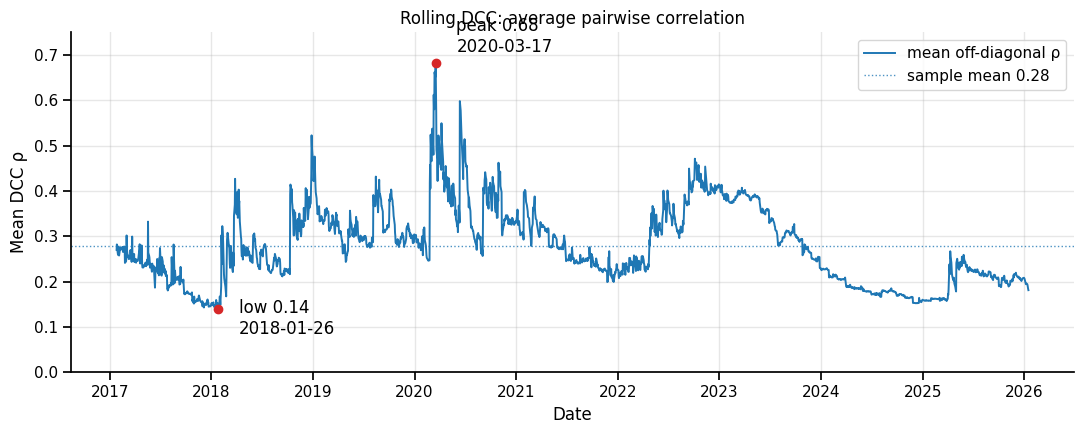

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(mean_corr.index, mean_corr.values, color="C0", lw=1.4, label="mean off-diagonal ρ")
ax.axhline(mean_corr.mean(), color="C0", ls=":", lw=1, alpha=0.8, label=f"sample mean {mean_corr.mean():.2f}")

peak_date, peak_val = mean_corr.idxmax(), mean_corr.max()
low_date, low_val = mean_corr.idxmin(), mean_corr.min()
ax.scatter([peak_date, low_date], [peak_val, low_val], color="C3", zorder=3)
ax.annotate(
    f"peak {peak_val:.2f}\n{peak_date.date()}",
    xy=(peak_date, peak_val),
    xytext=(15, 8),
    textcoords="offset points",
)
ax.annotate(
    f"low {low_val:.2f}\n{low_date.date()}",
    xy=(low_date, low_val),
    xytext=(15, -18),
    textcoords="offset points",
)

ax.set_title("Rolling DCC: average pairwise correlation")
ax.set_xlabel("Date")
ax.set_ylabel("Mean DCC ρ")
ax.set_ylim(0, 0.75)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

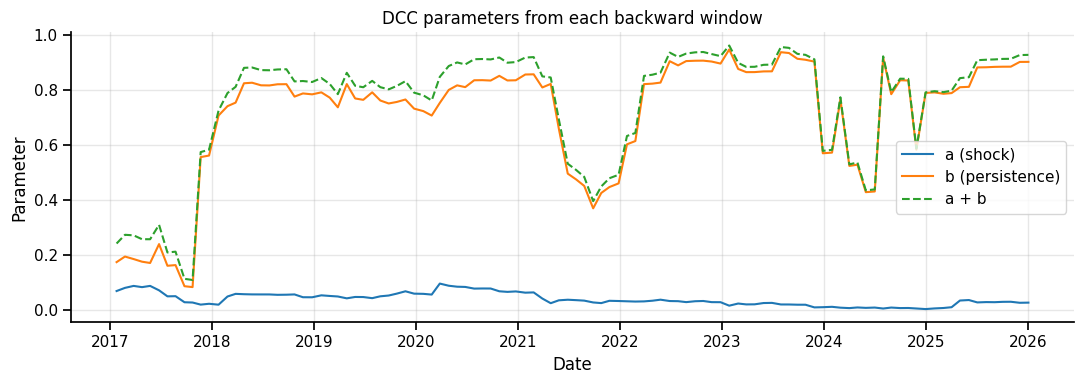

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(result.params["forecast_from"], result.params["a"], label="a (shock)")
ax.plot(result.params["forecast_from"], result.params["b"], label="b (persistence)")
ax.plot(result.params["forecast_from"], result.params["a_plus_b"], ls="--", label="a + b")
ax.set_title("DCC parameters from each backward window")
ax.set_xlabel("Date")
ax.set_ylabel("Parameter")
ax.legend()
fig.tight_layout()
plt.show()

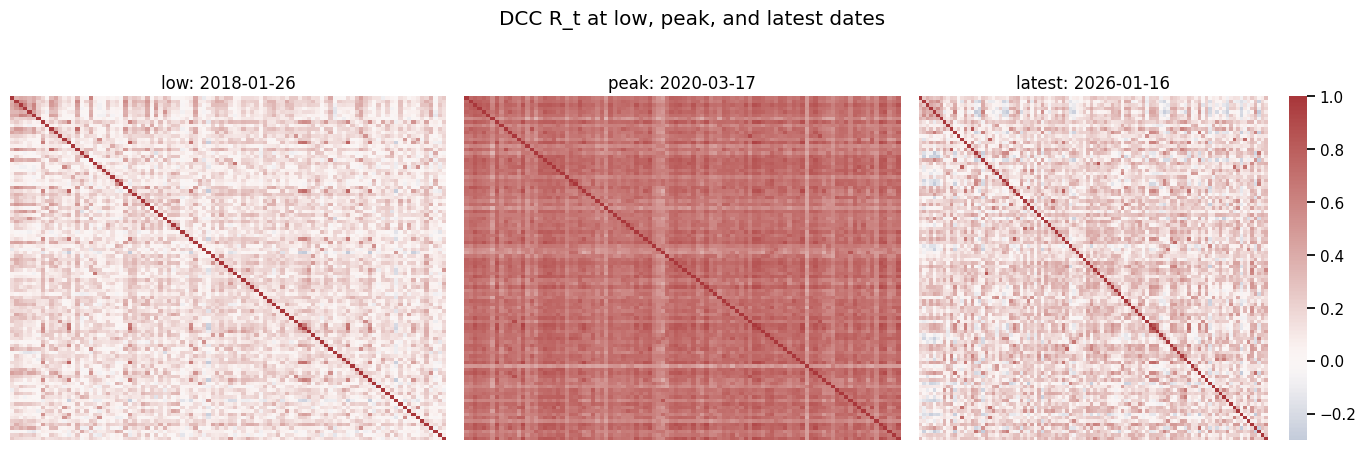

In [6]:
dates = {
    "low": mean_corr.idxmin(),
    "peak": mean_corr.idxmax(),
    "latest": result.dates[-1],
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (name, dt) in zip(axes, dates.items()):
    R = result.matrix_on(dt)
    sns.heatmap(
        R,
        ax=ax,
        cmap="vlag",
        center=0,
        vmin=-0.3,
        vmax=1.0,
        xticklabels=False,
        yticklabels=False,
        cbar=ax is axes[-1],
    )
    ax.set_title(f"{name}: {pd.Timestamp(dt).date()}")
fig.suptitle("DCC R_t at low, peak, and latest dates", y=1.02)
fig.tight_layout()
plt.show()

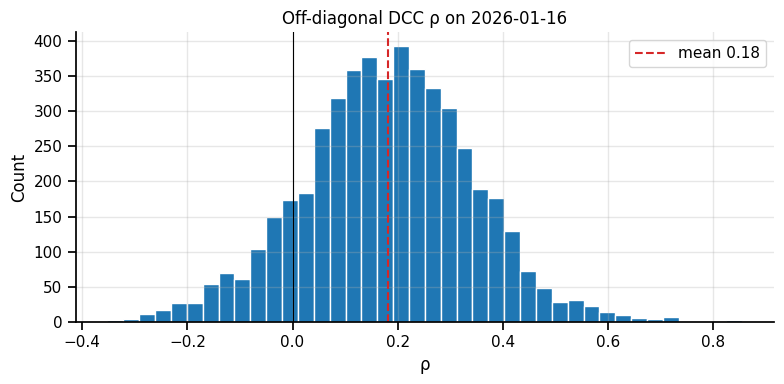

min=-0.352  mean=0.181  max=0.855  frac_neg=0.134


In [7]:
R_last = result.matrix_on(result.dates[-1])
off = R_last.values[np.triu_indices(len(R_last), 1)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(off, bins=40, color="C0", edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.axvline(off.mean(), color="C3", ls="--", label=f"mean {off.mean():.2f}")
ax.set_title(f"Off-diagonal DCC ρ on {result.dates[-1].date()}")
ax.set_xlabel("ρ")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()
print(
    f"min={off.min():.3f}  mean={off.mean():.3f}  max={off.max():.3f}  "
    f"frac_neg={(off < 0).mean():.3f}"
)

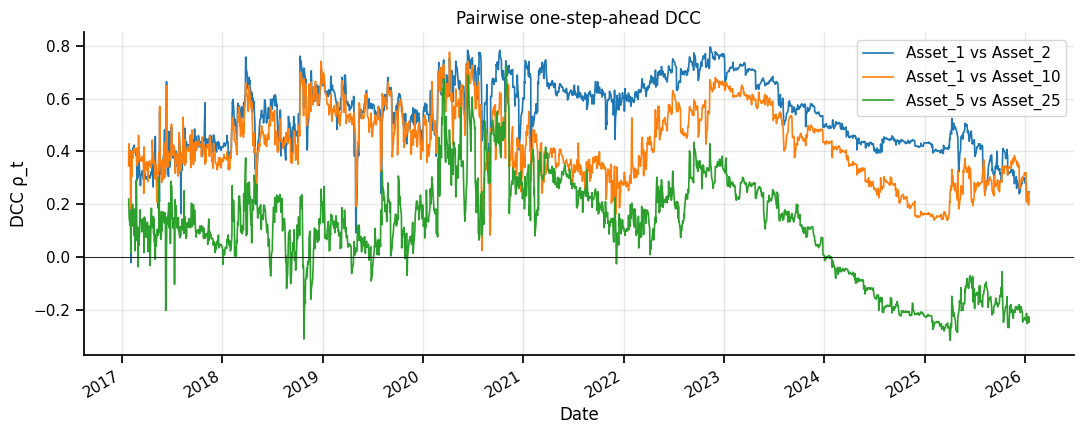

In [8]:
pairs = [("Asset_1", "Asset_2"), ("Asset_1", "Asset_10"), ("Asset_5", "Asset_25")]
fig, ax = plt.subplots(figsize=(11, 4.5))
for a, b in pairs:
    result.pair(a, b).plot(ax=ax, lw=1.2, label=f"{a} vs {b}")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Pairwise one-step-ahead DCC")
ax.set_xlabel("Date")
ax.set_ylabel("DCC ρ_t")
ax.legend()
fig.tight_layout()
plt.show()